# Imports

In [1]:
import sys, os
sys.path.append(os.path.abspath("../"))

In [71]:
%matplotlib inline
import matplotlib.pyplot as plt
from cycler import cycler
import numpy as np

In [72]:
from pynitride.mesh import Mesh, MaterialBlock, UniformLayer
from pynitride.material import Insulator, AlGaN
from pynitride.paramdb import nm, cm, eV
from pynitride.carriers import Semiclassical, Schrodinger, MultibandKP
from pynitride.solvers import SelfConsistentLoop, PoissonSolver, Equilibrium, Linear_Fermi

In [73]:
plt.rcParams['axes.linewidth']=3
plt.rcParams['lines.linewidth']=3
plt.rcParams['font.family']='sans-serif'
plt.rcParams['font.sans-serif']=['STIX']
plt.rcParams['mathtext.fontset']='stix'
plt.rcParams['font.size']=18

In [74]:
plt.rcParams['axes.prop_cycle'] = cycler(color='bgrcmyk')

# On-state

In [44]:
m=mon=Mesh(
    [
        MaterialBlock(Insulator("SiO2"),[
            UniformLayer("diel",8*nm)
        ]),
        MaterialBlock(AlGaN(),[
            UniformLayer("well",5*nm),
            UniformLayer("subs",500*nm,x=1,DeepDonorDonorConc=5.0e16/cm**3)
        ])
    ],
    max_dz=10*nm,
    refinements=[["diel/well",.01*nm,5],
                 ["well/subs",.01*nm,1.6]],
    boundary=[3*eV,'thick']
)

(0, 30)

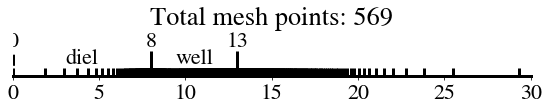

In [45]:
m.plot_mesh()
plt.xlim(0,30)

In [46]:
m.ensure_function_exists("p",value=0)
m.ensure_function_exists("n",value=0)
m.ensure_function_exists("pderiv",value=0)
m.ensure_function_exists("nderiv",value=0)
m.ensure_function_exists("fc",value=0)

In [47]:
m._functions.keys()

dict_keys(['p', 'n', 'pderiv', 'nderiv', 'fc'])

In [48]:
idw=m.interfaces_point[0][0]
m.fc[idw]=4.25e13/(1e7)**2/m.dzm[idw]

In [49]:
_,shm,scm=m.submesh_cover([8*nm,20*nm])

In [50]:
from pynitride.mesh import MidFunction

In [51]:
#Equilibrium(m)
Linear_Fermi(m,contacts={'gate':0,'idw':1,'source':2,'subs':3}).solve(**dict(gate=-5,idw=0,source=0,subs=0))
psm=PoissonSolver(m)
sc=SelfConsistentLoop(fieldsolvers=[psm],carriersolvers=[Schrodinger(shm),Semiclassical(scm)],)

In [52]:
sc.ramp_epsfactor(start=1e3,max_iter=20,dlefmin=.005)

Starting eps factor ramp from 1000 to 1
  Eps factor: 1.00e+03
  Starting SC loop
    iter:   0  err: 6.67e-01  activ: 1
    iter:   1  err: 1.92e-01  activ: 1
    iter:   2  err: 9.75e-02  activ: 1
    iter:   3  err: 7.45e-02  activ: 1
    iter:   4  err: 6.21e-02  activ: 1
    iter:   5  err: 5.38e-02  activ: 1
    iter:   6  err: 4.68e-02  activ: 1
    iter:   7  err: 4.15e-02  activ: 1
    iter:   8  err: 4.47e-02  activ: 1
    Retrying with Poisson activation=0.5
           iter:   8  err: 4.28e-02
    Retrying with Poisson activation=0.25
           iter:   8  err: 3.83e-02
    iter:   9  err: 3.25e-02  activ: 0.3
    iter:  10  err: 2.51e-02  activ: 0.36
    iter:  11  err: 1.73e-02  activ: 0.432
    iter:  12  err: 1.04e-02  activ: 0.5184
    iter:  13  err: 5.18e-03  activ: 0.62208
    iter:  14  err: 2.00e-03  activ: 0.746496
    iter:  15  err: 5.13e-04  activ: 0.895795
    iter:  16  err: 5.39e-05  activ: 1
    iter:  17  err: 6.65e-09  activ: 1
    Loop finished in 18 ite

In [53]:
if 1:
    mbkp=MultibandKP(shm,ktmax=2.5,num_kpoints=30)
    # This is some sort of boundary condition not sure what... not huge effect on density
    for H in mbkp._H:
        H[:6,:6]*=2
        H[-6:,-6:]*=2
    scl=SelfConsistentLoop(fieldsolvers=[psm],carriersolvers=[mbkp,Semiclassical(shm,'electron'),Semiclassical(scm)])
    scl.loop(tol=1e-8)

Assembling k.p matrices ...
Done assembly.
Starting SC loop
  iter:   0  err: 1.07e-01  activ: 1
  iter:   1  err: 1.48e-02  activ: 1
  iter:   2  err: 1.52e-03  activ: 1
  iter:   3  err: 2.04e-04  activ: 1
  iter:   4  err: 6.34e-05  activ: 1
  iter:   5  err: 1.96e-05  activ: 1
  iter:   6  err: 6.12e-06  activ: 1
  iter:   7  err: 1.93e-06  activ: 1
  iter:   8  err: 6.10e-07  activ: 1
  iter:   9  err: 1.93e-07  activ: 1
  iter:  10  err: 6.11e-08  activ: 1
  iter:  11  err: 1.94e-08  activ: 1
  iter:  12  err: 6.14e-09  activ: 1
  Loop finished in 13 iterations with err=6.13624e-09


In [54]:
mon.p.integrate(definite=True)/(1/cm**2)/1e13

Function(2.2335783630501385)

# Off-state

In [205]:
m=moff=Mesh(
    [
        MaterialBlock(Insulator("SiO2"),[
            UniformLayer("diel",8*nm)
        ]),
        MaterialBlock(AlGaN(),[
            UniformLayer("well",5*nm),
            UniformLayer("subs",500*nm,x=1,DeepDonorDonorConc=5.0e16/cm**3)
        ])
    ],
    max_dz=10*nm,
    refinements=[["diel/well",.01*nm,5],
                 ["well/subs",.01*nm,1.6]],
    boundary=[3*eV,'thick']
)

(0, 30)

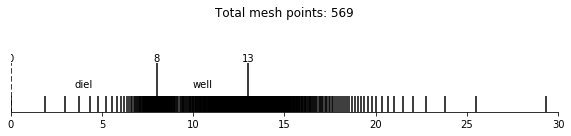

In [206]:
m.plot_mesh()
plt.xlim(0,30)

In [207]:
m.ensure_function_exists("p",value=0)
m.ensure_function_exists("n",value=0)
m.ensure_function_exists("pderiv",value=0)
m.ensure_function_exists("nderiv",value=0)
m.ensure_function_exists("fc",value=0)

In [208]:
m._functions.keys()

dict_keys(['p', 'n', 'pderiv', 'nderiv', 'fc'])

In [209]:
idw=m.interfaces_point[0][0]
m.fc[idw]=4.25e13/(1e7)**2/m.dzm[idw]

In [210]:
_,shm,scm=m.submesh_cover([8*nm,20*nm])

In [211]:
from pynitride.mesh import MidFunction

In [212]:
Equilibrium(m)
#Linear_Fermi(m,contacts={'gate':0,'idw':1,'source':2,'subs':3}).solve(**dict(gate=-5,idw=0,source=0,subs=0))
psm=PoissonSolver(m)
sc=SelfConsistentLoop(fieldsolvers=[psm],carriersolvers=[Schrodinger(shm),Semiclassical(scm)],)

In [213]:
sc.ramp_epsfactor(start=1e3,max_iter=20,dlefmin=.005)

Starting eps factor ramp from 1000 to 1
  Eps factor: 1.00e+03
  Starting SC loop
    iter:   0  err: 2.11e-06  activ: 1
    iter:   1  err: 1.04e-13  activ: 1
    Loop finished in  2 iterations with err=1.0419e-13
  Eps factor: 6.31e+02
  Starting SC loop
    iter:   0  err: 5.49e-03  activ: 1
    iter:   1  err: 4.66e-08  activ: 1
    Loop finished in  2 iterations with err=4.65672e-08
  Eps factor: 2.51e+02
  Starting SC loop
    iter:   0  err: 2.25e-02  activ: 1
    iter:   1  err: 1.37e-06  activ: 1
    iter:   2  err: 1.35e-13  activ: 1
    Loop finished in  3 iterations with err=1.34514e-13
  Eps factor: 7.94e+01
  Starting SC loop
    iter:   0  err: 8.08e-02  activ: 1
    iter:   1  err: 1.76e-05  activ: 1
    iter:   2  err: 6.39e-13  activ: 1
    Loop finished in  3 iterations with err=6.38924e-13
  Eps factor: 2.51e+01
  Starting SC loop
    iter:   0  err: 2.56e-01  activ: 1
    iter:   1  err: 2.07e-05  activ: 1
    iter:   2  err: 1.41e-15  activ: 1
    Loop finished in

In [122]:
if 1:
    mbkp=MultibandKP(shm,ktmax=2.5,num_kpoints=30)
    # This is some sort of boundary condition not sure what... not huge effect on density
    for H in mbkp._H:
        H[:6,:6]*=2
        H[-6:,-6:]*=2
    scl=SelfConsistentLoop(fieldsolvers=[psm],carriersolvers=[mbkp,Semiclassical(shm,'electron'),Semiclassical(scm)])
    scl.loop(tol=1e-8)

Assembling k.p matrices ...
Done assembly.
Starting SC loop
  iter:   0  err: 5.53e-02  activ: 1
  iter:   1  err: 2.65e-02  activ: 1
  iter:   2  err: 1.36e-02  activ: 1
  iter:   3  err: 3.86e-03  activ: 1
  iter:   4  err: 2.69e-04  activ: 1
  iter:   5  err: 1.95e-06  activ: 1
  iter:   6  err: 9.01e-08  activ: 1
  iter:   7  err: 8.21e-09  activ: 1
  Loop finished in  8 iterations with err=8.2099e-09


In [214]:
moff.p.integrate(definite=True)/(1/cm**2)/1e13

Function(1.103996461617824)

In [215]:
moff.n.integrate(definite=True)/(1/cm**2)/1e13

Function(1.20510964078368e-65)

# Access

In [29]:
m=macc=Mesh(
    [
        MaterialBlock(Insulator("SiO2"),[
            UniformLayer("diel",8*nm)
        ]),
        MaterialBlock(AlGaN(),[
            UniformLayer("dop",15*nm,MgAcceptorConc=4e19/cm**3),
            UniformLayer("well",8*nm),
            UniformLayer("subs",500*nm,x=1,DeepDonorDonorConc=5.0e16/cm**3)
        ])
    ],
    max_dz=10*nm,
    refinements=[["diel/dop",.01*nm,5],
                 [15,.2*nm,1.1],
                 ["well/subs",.01*nm,1.6]],
    boundary=[2*eV,'thick']
)

(0, 40)

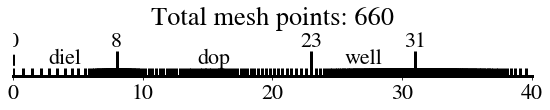

In [30]:
m.plot_mesh()
plt.xlim(0,40)

In [31]:
m.ensure_function_exists("p",value=0)
m.ensure_function_exists("n",value=0)
m.ensure_function_exists("pderiv",value=0)
m.ensure_function_exists("nderiv",value=0)
m.ensure_function_exists("fc",value=0)

In [32]:
m._functions.keys()

dict_keys(['p', 'n', 'pderiv', 'nderiv', 'fc'])

In [33]:
idw=m.interfaces_point[0][0]
m.fc[idw]=2.25e13/(1e7)**2/m.dzm[idw]

In [34]:
_,scmd,shm,scm=m.submesh_cover([8*nm,23*nm,35*nm])

In [35]:
from pynitride.mesh import MidFunction

In [36]:
Equilibrium(m)
#Linear_Fermi(m,contacts={'gate':0,'idw':1,'source':2,'subs':3}).solve(**dict(gate=-5,idw=0,source=0,subs=0))
psm=PoissonSolver(m)
sc=SelfConsistentLoop(fieldsolvers=[psm],carriersolvers=[Semiclassical(scmd),Schrodinger(shm),Semiclassical(scm)],)

In [37]:
sc.ramp_epsfactor(start=1e3,max_iter=20,dlefmin=.005)

Starting eps factor ramp from 1000 to 1
  Eps factor: 1.00e+03
  Starting SC loop
    iter:   0  err: 2.47e-01  activ: 1
    iter:   1  err: 6.48e-03  activ: 1
    iter:   2  err: 9.62e-06  activ: 1
    iter:   3  err: 7.70e-10  activ: 1
    Loop finished in  4 iterations with err=7.69971e-10
  Eps factor: 6.31e+02
  Starting SC loop
    iter:   0  err: 9.91e-02  activ: 1
    iter:   1  err: 2.19e-03  activ: 1
    iter:   2  err: 3.89e-07  activ: 1
    Loop finished in  3 iterations with err=3.88596e-07
  Eps factor: 2.51e+02
  Starting SC loop
    iter:   0  err: 2.12e-01  activ: 1
    iter:   1  err: 1.62e-02  activ: 1
    iter:   2  err: 7.87e-05  activ: 1
    iter:   3  err: 1.67e-09  activ: 1
    Loop finished in  4 iterations with err=1.67437e-09
  Eps factor: 7.94e+01
  Starting SC loop
    iter:   0  err: 2.50e-01  activ: 1
    iter:   1  err: 7.78e-02  activ: 1
    iter:   2  err: 1.47e-02  activ: 1
    iter:   3  err: 4.01e-04  activ: 1
    iter:   4  err: 3.19e-07  activ: 1


    iter:   3  err: 7.91e-02  activ: 1
    iter:   4  err: 3.19e-02  activ: 1
    iter:   5  err: 4.78e-03  activ: 1
    iter:   6  err: 2.27e-04  activ: 1
    iter:   7  err: 2.19e-06  activ: 1
    iter:   8  err: 8.59e-08  activ: 1
    Loop finished in  9 iterations with err=8.59289e-08
  Eps factor: 8.54e+00
  Starting SC loop
    iter:   0  err: 3.10e-01  activ: 1
    iter:   1  err: 2.10e-02  activ: 1
    iter:   2  err: 3.79e-03  activ: 1
    iter:   3  err: 1.49e-04  activ: 1
    iter:   4  err: 5.42e-06  activ: 1
    iter:   5  err: 4.04e-07  activ: 1
    Loop finished in  6 iterations with err=4.03991e-07
  Eps factor: 4.80e+00
  Starting SC loop
    iter:   0  err: 4.74e-01  activ: 1
    iter:   1  err: 7.28e-01  activ: 1
    Retrying with Poisson activation=0.5
           iter:   1  err: 7.07e-02
    iter:   2  err: 3.38e-02  activ: 0.6
    iter:   3  err: 1.49e-02  activ: 0.72
    iter:   4  err: 4.62e-03  activ: 0.864
    iter:   5  err: 6.98e-04  activ: 1
    iter:   6  e

In [38]:
if 1:
    mbkp=MultibandKP(shm,ktmax=2.5,num_kpoints=30)
    # This is some sort of boundary condition not sure what... not huge effect on density
    for H in mbkp._H:
        H[:6,:6]*=2
        H[-6:,-6:]*=2
    scl=SelfConsistentLoop(fieldsolvers=[psm],carriersolvers=[Semiclassical(scmd),mbkp,Semiclassical(shm,'electron'),Semiclassical(scm)])
    scl.loop(tol=1e-8)

Assembling k.p matrices ...
Done assembly.
Starting SC loop
  iter:   0  err: 1.72e-01  activ: 1
  iter:   1  err: 7.96e-02  activ: 1
  iter:   2  err: 2.28e-02  activ: 1
  iter:   3  err: 9.50e-04  activ: 1
  iter:   4  err: 8.47e-05  activ: 1
  iter:   5  err: 2.25e-05  activ: 1
  iter:   6  err: 5.87e-06  activ: 1
  iter:   7  err: 1.52e-06  activ: 1
  iter:   8  err: 3.92e-07  activ: 1
  iter:   9  err: 1.01e-07  activ: 1
  iter:  10  err: 2.60e-08  activ: 1
  iter:  11  err: 6.67e-09  activ: 1
  Loop finished in 12 iterations with err=6.6694e-09


# Make figure

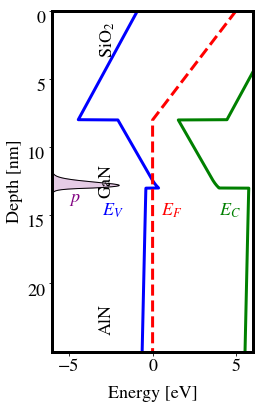

In [75]:
def fig_pFET_bd(ax,m):
    ax.plot(m.Ev,m.zp)
    ax.plot(m.Ec,m.zp)
    ax.plot(m.EF,m.zp,'--')
    ax.set_yticks(np.linspace(0,20,5))
    ax.set_ylim(25,0)
    ax.set_ylabel("Depth [nm]")
    #plt.gca().yaxis.set_label_position("right")
    #plt.gca().yaxis.tick_right()
    ax.set_xlim(-6,6)
    plt.setp(ax.get_yticklabels(),va='top')
    #plt.gca().add_artist(Ellipse((-4,5.5),3,6,facecolor='none',edgecolor='k'))
    #plt.gca().add_artist(Ellipse((5,5.5),3,6,facecolor='none',edgecolor='k'))
    
    ax.set_xlabel("Energy [eV]")
    ax.xaxis.set_label_coords(.5,-.1)
    ax.text(4,15,"$E_C$",color='g',transform=ax.transData)
    ax.text(-3,15,"$E_V$",color='b',transform=ax.transData)
    ax.text(.5,15,"$E_F$",color='r',transform=ax.transData)
    
    ax2=ax.twiny()
    xmax=1200
    ax2.plot(m.p*(1e7)**3/1e18,m.zp,'k',linewidth=1)
    ax2.fill_betweenx(m.zp,m.p*(1e7)**3/1e18,color='purple',alpha=.2)
    ax2.set_xlim(0,xmax)
    ax2.set_xticks([])
    ax2.text(100,14,"$p$",color='purple',transform=ax2.transData)

    if 0:
        hl=nno.read(nno.dir+"/densities/density1Dhl"+suffix+".dat")
        el=nno.read(nno.dir+"/densities/density1Del"+suffix+".dat")
        ax2.plot(hl['hl[1e18/cm3]'],hl['position[nm]'],'k',linewidth=1)
        ax2.plot(xmax-el['el[1e18/cm3]'],el['position[nm]'],'k',linewidth=1)
        ax2.fill_betweenx(hl['position[nm]'],hl['hl[1e18/cm3]'],color='purple',alpha=.2)
        ax2.fill_betweenx(el['position[nm]'],xmax-el['el[1e18/cm3]'],x2=xmax,color='orange',alpha=.6)
        ax2.set_xlim(0,xmax)
        ax2.set_xticks([])
        ax2.text(100,14,"$p$",color='purple',transform=ax2.transData)
        #print("hl {:.2g}x10^13/cm^2".format(np.trapz(hl['hl[1e18/cm3]']*1e18*1e-7,hl['position[nm]'])/1e13))
        #print("el {:.2g}x10^13/cm^2".format(np.trapz(el['el[1e18/cm3]']*1e18*1e-7,el['position[nm]'])/1e13))

    ax2.text(.23,.05,"AlN",transform=ax2.transAxes, rotation=90, ha='left', va='bottom')
    ax2.text(.23,.45,"GaN",transform=ax2.transAxes, rotation=90, ha='left', va='bottom')
    ax2.text(.23,.86,"SiO$_2$",transform=ax2.transAxes, rotation=90, ha='left', va='bottom')

fig=plt.figure(figsize=(4,6),frameon=False)
ax=plt.subplot(111)
fig_pFET_bd(ax,mon)
plt.tight_layout()    
plt.savefig('IEDM/pFET_on_bd.png')

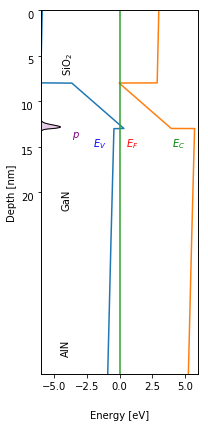

In [156]:
# Off
fig=plt.figure(figsize=(3,6),frameon=False)
ax=plt.subplot(111)
fig_pFET_bd(ax,moff)
plt.tight_layout()    
plt.savefig('IEDM/pFET_bd.png')

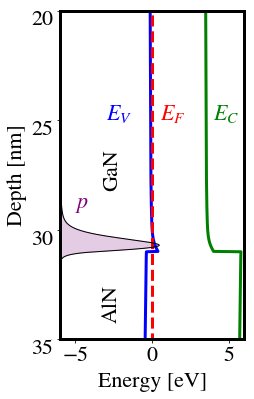

In [21]:
# Acc
def fig_pFET_bd(ax,m):
    ax.plot(m.Ev,m.zp)
    ax.plot(m.Ec,m.zp)
    ax.plot(m.EF,m.zp,'--')
    ax.set_yticks(np.linspace(20,40,5))
    ax.set_ylim(25,0)
    ax.set_ylabel("Depth [nm]")
    #plt.gca().yaxis.set_label_position("right")
    #plt.gca().yaxis.tick_right()
    ax.set_xlim(-6,6)
    plt.setp(ax.get_yticklabels(),va='top')
    #plt.gca().add_artist(Ellipse((-4,5.5),3,6,facecolor='none',edgecolor='k'))
    #plt.gca().add_artist(Ellipse((5,5.5),3,6,facecolor='none',edgecolor='k'))
    
    ax.set_xlabel("Energy [eV]")
    ax.xaxis.set_label_coords(.5,-.1)
    ax.text(4, 25,"$E_C$",color='g',transform=ax.transData)
    ax.text(-3,25,"$E_V$",color='b',transform=ax.transData)
    ax.text(.5,25,"$E_F$",color='r',transform=ax.transData)
    
    ax2=ax.twiny()
    xmax=1200
    ax2.plot(m.p*(1e7)**3/1e18,m.zp,'k',linewidth=1)
    ax2.fill_betweenx(m.zp,m.p*(1e7)**3/1e18,color='purple',alpha=.2)
    ax2.set_xlim(0,xmax)
    ax2.set_xticks([])
    ax2.text(100,29,"$p$",color='purple',transform=ax2.transData)

    if 0:
        hl=nno.read(nno.dir+"/densities/density1Dhl"+suffix+".dat")
        el=nno.read(nno.dir+"/densities/density1Del"+suffix+".dat")
        ax2.plot(hl['hl[1e18/cm3]'],hl['position[nm]'],'k',linewidth=1)
        ax2.plot(xmax-el['el[1e18/cm3]'],el['position[nm]'],'k',linewidth=1)
        ax2.fill_betweenx(hl['position[nm]'],hl['hl[1e18/cm3]'],color='purple',alpha=.2)
        ax2.fill_betweenx(el['position[nm]'],xmax-el['el[1e18/cm3]'],x2=xmax,color='orange',alpha=.6)
        ax2.set_xlim(0,xmax)
        ax2.set_xticks([])
        ax2.text(100,14,"$p$",color='purple',transform=ax2.transData)
        #print("hl {:.2g}x10^13/cm^2".format(np.trapz(hl['hl[1e18/cm3]']*1e18*1e-7,hl['position[nm]'])/1e13))
        #print("el {:.2g}x10^13/cm^2".format(np.trapz(el['el[1e18/cm3]']*1e18*1e-7,el['position[nm]'])/1e13))

    ax2.text(.23,.05,"AlN",transform=ax2.transAxes, rotation=90, ha='left', va='bottom')
    ax2.text(.23,.45,"GaN",transform=ax2.transAxes, rotation=90, ha='left', va='bottom')
    #ax2.text(.23,.86,"SiO$_2$",transform=ax2.transAxes, rotation=90, ha='left', va='bottom')


fig=plt.figure(figsize=(4,6),frameon=False)
ax=plt.subplot(111)
fig_pFET_bd(ax,macc)
plt.tight_layout()  
plt.sca(plt.gcf().axes[0])
plt.ylim(35,20)
plt.savefig('IEDM/pFET_acc_bd.png')

In [22]:
macc.p.integrate(definite=True)/(1/cm**2)/1e13

Function(4.968261022398418)

# Dispersion

In [55]:
from scipy import gradient
from scipy.interpolate import interp1d
from matplotlib.transforms import Bbox

In [56]:
plt.rcParams['font.size']=22

In [57]:
def DOS_of_one(k_t,bs1_t,E):
    kt2=np.ravel(interp1d(np.ravel(bs1_t),np.ravel(k_t)**2,fill_value=0,bounds_error=False,kind='quadratic')(E))
    N=1/(2*np.pi)**2 * np.pi *kt2
    DOS=gradient(N,E[1]-E[0])
    return -DOS
E=np.linspace(.1,-.1,1200)
DOS=0

In [58]:
mbkp._kt,mbkp._mesh.kpen[:,0,0]*1e3

(array([ 0.        ,  0.0862069 ,  0.17241379,  0.25862069,  0.34482759,
         0.43103448,  0.51724138,  0.60344828,  0.68965517,  0.77586207,
         0.86206897,  0.94827586,  1.03448276,  1.12068966,  1.20689655,
         1.29310345,  1.37931034,  1.46551724,  1.55172414,  1.63793103,
         1.72413793,  1.81034483,  1.89655172,  1.98275862,  2.06896552,
         2.15517241,  2.24137931,  2.32758621,  2.4137931 ,  2.5       ]),
 Function([  12.95328623,   12.44706139,   11.1004136 ,    9.3207434 ,
           7.46437033,    5.62686763,    3.74574482,    1.74287229,
          -0.43538433,   -2.82139516,   -5.43439659,   -8.28602714,
         -11.38350677,  -14.73141392,  -18.3326928 ,  -22.18923941,
         -26.30225289,  -30.67245196,  -35.30021188,  -40.18565287,
         -45.32869829,  -50.72911331,  -56.3865307 ,  -62.30046794,
         -68.47033821,  -74.89545706,  -81.57504585,  -88.5082326 ,
         -95.69405094, -103.13143727]))

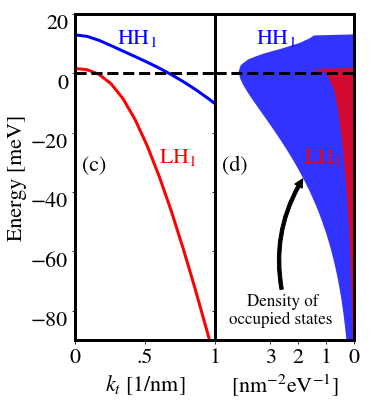

In [69]:
def fig_pFET_disp(ax):

    ax.axis('off')
    ax1=plt.axes(Bbox.from_extents(0,0,.5,1).transformed(ax.transAxes+ax.figure.transFigure.inverted()))
    ax2=plt.axes(Bbox.from_extents(.5,0,1,1).transformed(ax.transAxes+ax.figure.transFigure.inverted()),sharey=ax1)
    
    ### Dispersion plot
    
    # Plot the first two levels
    k1,e1=mbkp._kt,mbkp._mesh.kpen[:,0,0]
    ax1.plot(k1,e1*1e3,'b',label="HH-1")
    k3,e3=mbkp._kt,mbkp._mesh.kpen[:,2,0]
    ax1.plot(k3,e3*1e3,'r',label="LH-1")
    
    # Also plot the next level to make sure it's offscreen!
    #ax1.plot(disp_hg['k[1/nm]'],disp_hg['ev_5[eV]']*1e3,'b',label="HH-2")
    
    # Extract DOS
    DOS1=2*DOS_of_one(k1,e1,E)
    DOS3=2*DOS_of_one(k3,e3,E)
    
    # Label bands
    ax1.text(.3,10,r"HH$_1$",color='b',transform=ax1.transData)
    ax1.text(.6,-30,r"LH$_1$",color='r',transform=ax1.transData)
    #ax1.text(.4,-8,r"$E_F$",color='k',transform=ax1.transData)
    ax1.axhline(0,linestyle='--',color='k')
    
    # Label axes
    ax1.yaxis.set_label_text(r"Energy [meV]")
    #ax1.yaxis.set_label_coords(-.2,.72)
    ax1.xaxis.set_label_text(r"$k_t$ [1/nm]")
    ax1.xaxis.set_label_coords(.5,-.1)
    plt.setp(ax1.get_yticklabels(),va='top')
    
    # Set limits and ticks
    ax1.set_ylim(-90,20);
    ax1.set_xlim(0,1)
    ax1.set_xticks([0,.5,1])
    ax1.set_xticklabels(["0",".5","1"])

    ### DOS plot
    
    # Plot occupieds
    ax2.fill_betweenx(E*1e3,DOS1*(1/(1+np.exp(-E/.026))),0,facecolor='b',edgecolor='k',linewidth=0,alpha=.8,label='HH-1')
    ax2.fill_betweenx(E*1e3,(DOS3)*(1/(1+np.exp(-E/.026))),0,facecolor='r',edgecolor='k',linewidth=0,alpha=.8,label='LH-1')
    ax2.axhline(0,linestyle='--',color='k')
    
    # Label and set limits
    ax2.set_xlim(5,0)
    ax2.set_xticks([0,1,2,3])
    ax2.set_xlabel("[nm$^{-2}$eV$^{-1}$]")
    ax2.xaxis.set_label_position("bottom")
    ax2.xaxis.tick_bottom()
    ax2.xaxis.set_label_coords(.5,-.1)
    plt.setp(ax2.get_yticklabels(),visible=False)

    # Label DOSs
    plt.text(3.5,10,r"HH$_1$",color='b')
    plt.text(1.8,-30,r"LH$_1$",color='r')

    plt.annotate("Density of\noccupied states ",(1.8,-35),xytext=(2.57,-80),ha='center',va='center',fontsize=17,
                 arrowprops=dict(arrowstyle='simple',color='k',connectionstyle='arc3,rad=-.2',relpos=(.5,1)))

fig=plt.figure(figsize=(5,6),frameon=False)
ax=plt.subplot(111)
fig_pFET_disp(ax)
plt.text(.05,.52,"(d)",transform=plt.gca().transAxes)
plt.text(.05-1,.52,"(c)",transform=plt.gca().transAxes)
#plt.tight_layout()
plt.savefig("pFET_disp.png",bbox_inches=Bbox.from_extents([-.5,-.05,5,5.5]))

# IDK

0.3119485662951135


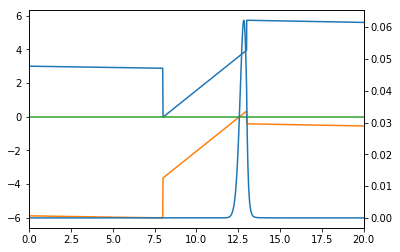

In [128]:
plt.plot(m.zp,m.Ec)
plt.plot(m.zp,m.Ev)
plt.plot(m.zp,m.EF)
plt.xlim(0,20)
plt.twinx()
plt.plot(m.zp,m.p)
print(m.p.integrate(definite=True)/(1/cm**2)/1e13)

rho  0.4140751528714609
DP   -0.05594831216217734


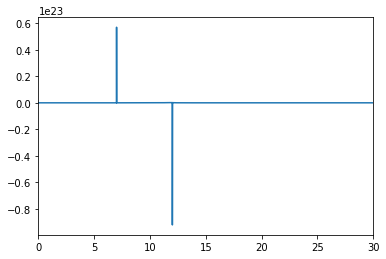

In [41]:
plt.plot(m.zp,m.rho/(1/cm**3))
plt.xlim(0,30)
mask=(m.zp>2)*(m.zp<10)
print("rho ",np.trapz(m.rho[mask],m.zp[mask]))
print("DP  ",np.trapz(m.DP[mask],m.zp[mask]))

In [40]:
mask=(m.zp>10)*(m.zp<20)
print("DP  ",np.trapz(m.DP[mask],m.zp[mask]))

DP   -0.5057875560786601


(0, 30)

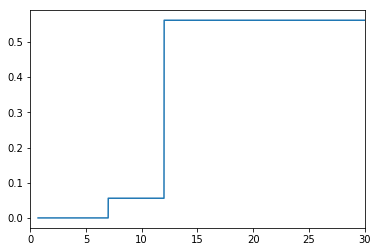

In [46]:
plt.plot(m.zm,m.get("P",default=0.0))
plt.xlim(0,30)

In [23]:
m.Ec[0]

7.0